# Kalibracja modelu 


Kalibracja parametrów symulacji odbędzie się na podstawie danych historycznych notowań złota LBMA oraz kursu USD/PLN. 


**Można coś powiedzieć o innych notowaniach złota**

In [114]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import norm

In [115]:
gold_data = pd.read_csv('londonfixes-current-clean_1990_.csv')
gold_df = gold_data[["Date", "Gold PM Fix"]].copy()

usdpln_df = pd.read_csv("usdpln_d.csv", usecols=["Data", "Zamkniecie"])

usdpln_df.rename(columns={"Data": "Date", "Zamkniecie": "USDPLN"}, inplace=True)
gold_df.rename(columns={"Gold PM Fix": "Gold"}, inplace=True)

usdpln_df['Date'] = pd.to_datetime(usdpln_df['Date'])
gold_df['Date'] = pd.to_datetime(gold_df['Date'])

df = pd.merge(gold_df, usdpln_df, on="Date", how="inner")
df['Gold'] = pd.to_numeric(df['Gold'], errors='coerce')
df = df[df['Gold'] > 0]
df.sort_values(by="Date", inplace=True)
df.set_index("Date", inplace=True)
df.dropna(inplace=True)

df = df.loc['2014-06-29':'2024-06-29']




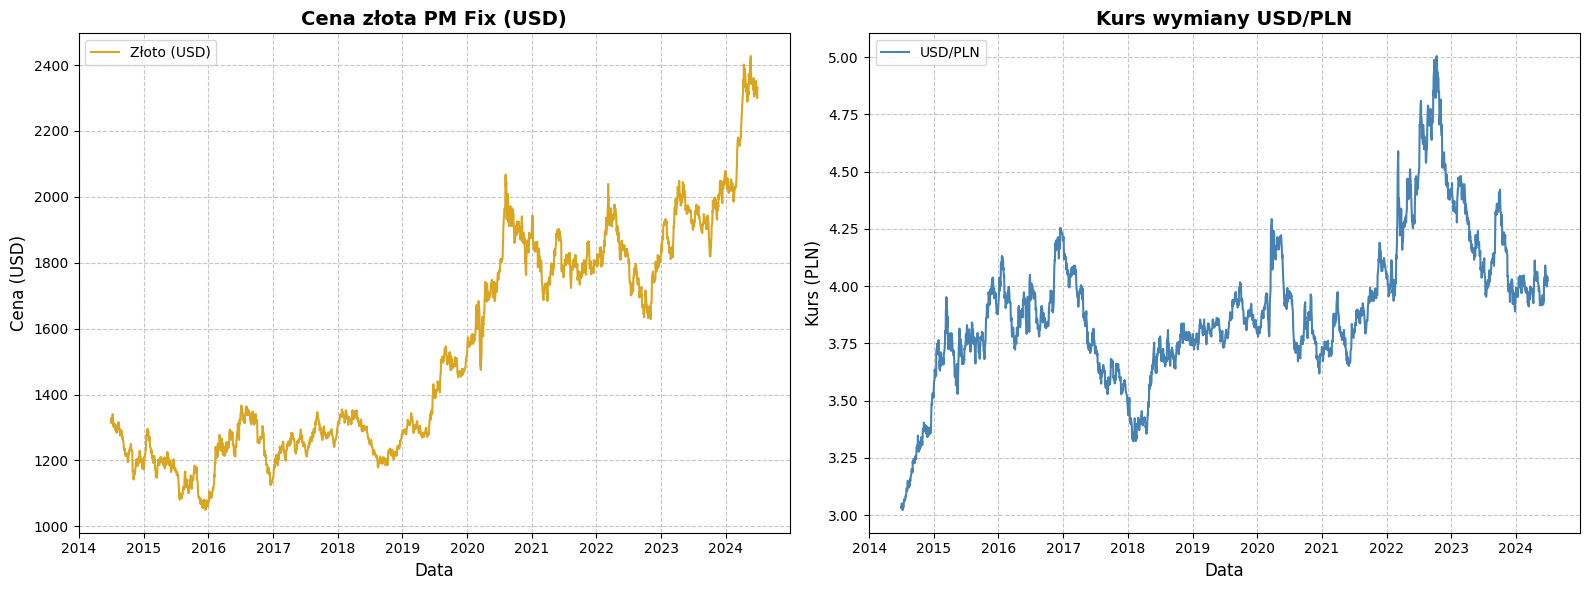

In [116]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

ax1.plot(df.index, df['Gold'], color='goldenrod', label='Złoto (USD)')
ax1.set_title('Cena złota PM Fix (USD)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Cena (USD)', fontsize=12)
ax1.set_xlabel('Data', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend(loc='upper left')

ax2.plot(df.index, df['USDPLN'], color='steelblue', label='USD/PLN')
ax2.set_title('Kurs wymiany USD/PLN', fontsize=14, fontweight='bold')
ax2.set_ylabel('Kurs (PLN)', fontsize=12)
ax2.set_xlabel('Data', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [117]:
df['Gold_PLN'] = df['Gold'] * df['USDPLN']

returns = df.pct_change().dropna()
log_returns = np.log(df / df.shift(1)).dropna()

num_of_days = 252

end_date = pd.to_datetime('2024-06-30')
periods = {
    '1Y': end_date - pd.DateOffset(years=1),
    # '2Y': end_date - pd.DateOffset(years=2),
    # '3Y': end_date - pd.DateOffset(years=3),
    # '5Y': end_date - pd.DateOffset(years=5),
    # '7Y': end_date - pd.DateOffset(years=7),
    # '10Y': end_date - pd.DateOffset(years=10),
}

for label, start_date in periods.items():
    period_log_returns = log_returns.loc[start_date:end_date]
    
    volatility = period_log_returns.std() * np.sqrt(num_of_days)
    drift = period_log_returns.mean() * num_of_days
    correlation = period_log_returns.corr()
    
    print(f"--- Okres: {label} ---")
    print("Drift:")
    print(drift.round(4).to_string())
    print("\nVolatility:")
    print(volatility.round(4).to_string())
    print("\nCorrelation Matrix:")
    print(correlation.round(4).to_string())
    print("-" * 40)

--- Okres: 1Y ---
Drift:
Gold        0.2062
USDPLN     -0.0169
Gold_PLN    0.1893

Volatility:
Gold        0.1289
USDPLN      0.1042
Gold_PLN    0.1439

Correlation Matrix:
            Gold  USDPLN  Gold_PLN
Gold      1.0000 -0.2525    0.7133
USDPLN   -0.2525  1.0000    0.4981
Gold_PLN  0.7133  0.4981    1.0000
----------------------------------------


# Symulacje

In [118]:
def simulate_paths(S0, mu, sigma, dt, T, n_paths):
    n_steps = int(round(T / dt))
    time = np.linspace(0, T, n_steps + 1)

    Z = np.random.standard_normal((n_steps, n_paths))
    dW = Z * np.sqrt(dt)
    W = np.vstack([np.zeros((1, n_paths)), np.cumsum(dW, axis=0)])

    drift = (mu - 0.5 * sigma**2) * time.reshape(-1,1)
    diffusion = sigma * W
    S = S0 * np.exp(drift + diffusion)

    return time, S

In [119]:
def simulate_correlated_paths(S1_0, S2_0, mu1, mu2, sigma1, sigma2, rho, dt, T, n_paths):
    n_steps = int(round(T / dt))
    time = np.linspace(0, T, n_steps + 1)

    Z1 = np.random.standard_normal((n_steps, n_paths))
    Z2 = np.random.standard_normal((n_steps, n_paths))
    
    Z2_corr = rho * Z1 + np.sqrt(1.0 - rho**2) * Z2
    
    W1 = np.vstack([np.zeros((1, n_paths)), np.cumsum(Z1 * np.sqrt(dt), axis=0)])
    W2 = np.vstack([np.zeros((1, n_paths)), np.cumsum(Z2_corr * np.sqrt(dt), axis=0)])

    time_2d = time.reshape(-1, 1)

    S1 = S1_0 * np.exp((mu1 - 0.5 * sigma1**2) * time_2d + sigma1 * W1)
    S2 = S2_0 * np.exp((mu2 - 0.5 * sigma2**2) * time_2d + sigma2 * W2)
    
    return time, S1, S2

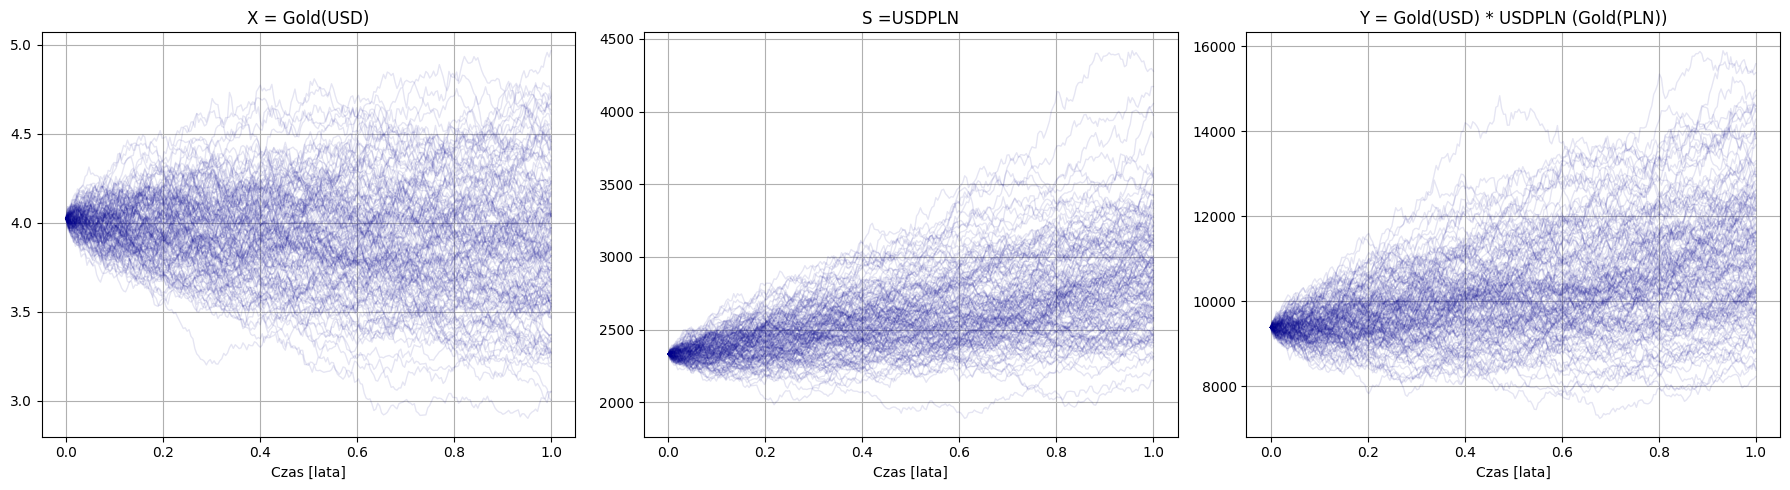

In [120]:
set_seed = 42

T = 1.0
N = 252
dt = T / N
n_paths = 1000
S0_gold = df['Gold'].iloc[-1]
S0_usdpln = df['USDPLN'].iloc[-1]
K = 1.0
# S0_gold_pln = df['Gold_PLN'].iloc[-1]

mu1 = drift['Gold']
mu2 = drift['USDPLN']
sigma1 = volatility['Gold']
sigma2 = volatility['USDPLN']
rho = correlation.loc['Gold', 'USDPLN']
r_pln = 0.05
r_usd = 0.02
# rho_SX = correlation.loc['Gold', 'USDPLN']
# rho_XY = correlation.loc['USDPLN', 'Gold_PLN']

t, X, S = simulate_correlated_paths(S0_gold, S0_usdpln, mu1, mu2, sigma1, sigma2, rho, dt, T, n_paths)

Y = X * S

n_plot = 150

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

col = 'darkblue'
alpha = 0.1

axes[0].plot(t, S[:, :n_plot], lw=1, color=col, alpha=alpha)
axes[0].set_title('X = Gold(USD)')

axes[1].plot(t, X[:, :n_plot], lw=1, color=col, alpha=alpha)
axes[1].set_title('S =USDPLN')

axes[2].plot(t, Y[:, :n_plot], lw=1, color=col, alpha=alpha)
axes[2].set_title('Y = Gold(USD) * USDPLN (Gold(PLN))')

for ax in axes:
    ax.set_xlabel('Czas [lata]')
    ax.grid(True)

plt.tight_layout()
plt.show()

# Delta-Hedging


In [121]:
def d1_d2(S, S0, K, tau, r_usd, rho, sigma_S, sigma_X):
    if tau <= 1e-12:
        return 0.0, 0.0
        
    d1 = (np.log(S / (K * S0)) + (r_usd - rho * sigma_X * sigma_S + 0.5 * sigma_S**2) * tau) / (sigma_S * np.sqrt(tau))
    d2 = d1 - sigma_S * np.sqrt(tau)
    return d1, d2

In [122]:
def quanto(S, S0, K, tau, r_pln, r_usd, rho, sigma_S, sigma_X):
    if tau <= 1e-12:
        return 100 * np.maximum(S/S0 - K, 0) 
        
    d1, d2 = d1_d2(S, S0, K, tau, r_usd, rho, sigma_S, sigma_X)
    
    q = r_pln - r_usd + rho * sigma_X * sigma_S
    
    price = (100 / S0) * (S * np.exp(-q * tau) * norm.cdf(d1) - K * S0 * np.exp(-r_pln * tau) * norm.cdf(d2))
    return price

In [123]:
def delta_hedging_step(S, X, delta_S_old, delta_X_old, cash_PLN,
                       S0, K, tau, r_pln, r_usd, rho, sigma_S, sigma_X, dt):
    
    cash_PLN = cash_PLN * np.exp(r_pln * dt)    # odsetki od gotówki
    delta_X_old = delta_X_old * np.exp(r_usd * dt)  # odsetki od gotówki w USD

    Pi = delta_S_old * S * X + delta_X_old * X + cash_PLN   # Wartość portfela przed rebalansowaniem

    d1, _ = d1_d2(S, S0, K, tau, r_usd, rho, sigma_S, sigma_X)
    q = r_pln - r_usd + rho * sigma_X * sigma_S # Magiczne q od Ewy
    dV_dS = (100 / S0) * np.exp(-q * tau) * norm.cdf(d1)    # Pochodna ze wzoru

    # Nowe delty
    delta_S_new = (1 / X) * dV_dS
    delta_X_new = -(S / X) * dV_dS

    # Aktualizacja gotówki w PLN 
    cash_PLN = cash_PLN - (delta_S_new - delta_S_old) * S * X - (delta_X_new - delta_X_old) * X
    
    return delta_S_new, delta_X_new, cash_PLN, Pi

In [124]:
def simulate_delta_hedging(time, S, X, S0, K, T, r_pln, r_usd, rho, sigma_S, sigma_X, dt):
    n_steps = len(time) - 1

    # Śledzimy skład portfela
    delta_S = np.zeros_like(S)
    delta_X = np.zeros_like(X)
    cash_PLN = np.zeros_like(S)

    Pi = np.zeros_like(S) # Śledzimy wartość portfela

    # Wartość opcji w dniu 0
    V0 = quanto(S[0], S0, K, T, r_pln, r_usd, rho, sigma_S, sigma_X)
    
    # Pierwszy hedging
    delta_S[0], delta_X[0], cash_PLN[0], Pi[0] = delta_hedging_step(
        S[0], X[0], 0, 0, V0, 
        S0, K, T, r_pln, r_usd, rho, sigma_S, sigma_X, 0
    )

    # Symulacja życia opcji
    for i in range(1, n_steps):
        tau = T - time[i]
        
        delta_S[i], delta_X[i], cash_PLN[i], Pi[i] = delta_hedging_step(
            S[i], X[i], delta_S[i-1], delta_X[i-1], cash_PLN[i-1],
            S0, K, tau, r_pln, r_usd, rho, sigma_S, sigma_X, dt
        )

    # Ostatni dzień (bez rebalansowania)
    delta_S[-1] = delta_S[-2]
    delta_X[-1] = delta_X[-2] * np.exp(r_usd * dt)
    cash_PLN[-1] = cash_PLN[-2] * np.exp(r_pln * dt)
    
    # Wartość portfela na koniec
    Pi[-1] = delta_S[-1] * S[-1] * X[-1] + delta_X[-1] * X[-1] + cash_PLN[-1]
    
    payoff = 100 * np.maximum(S[-1]/S0 - K, 0)
    hedging_error = Pi[-1] - payoff # Być może trzeba spieniężyć portfel, do przedyskutowania

    return time, S, X, Pi, payoff, hedging_error

## Ładnie widać, ale nic nie widać

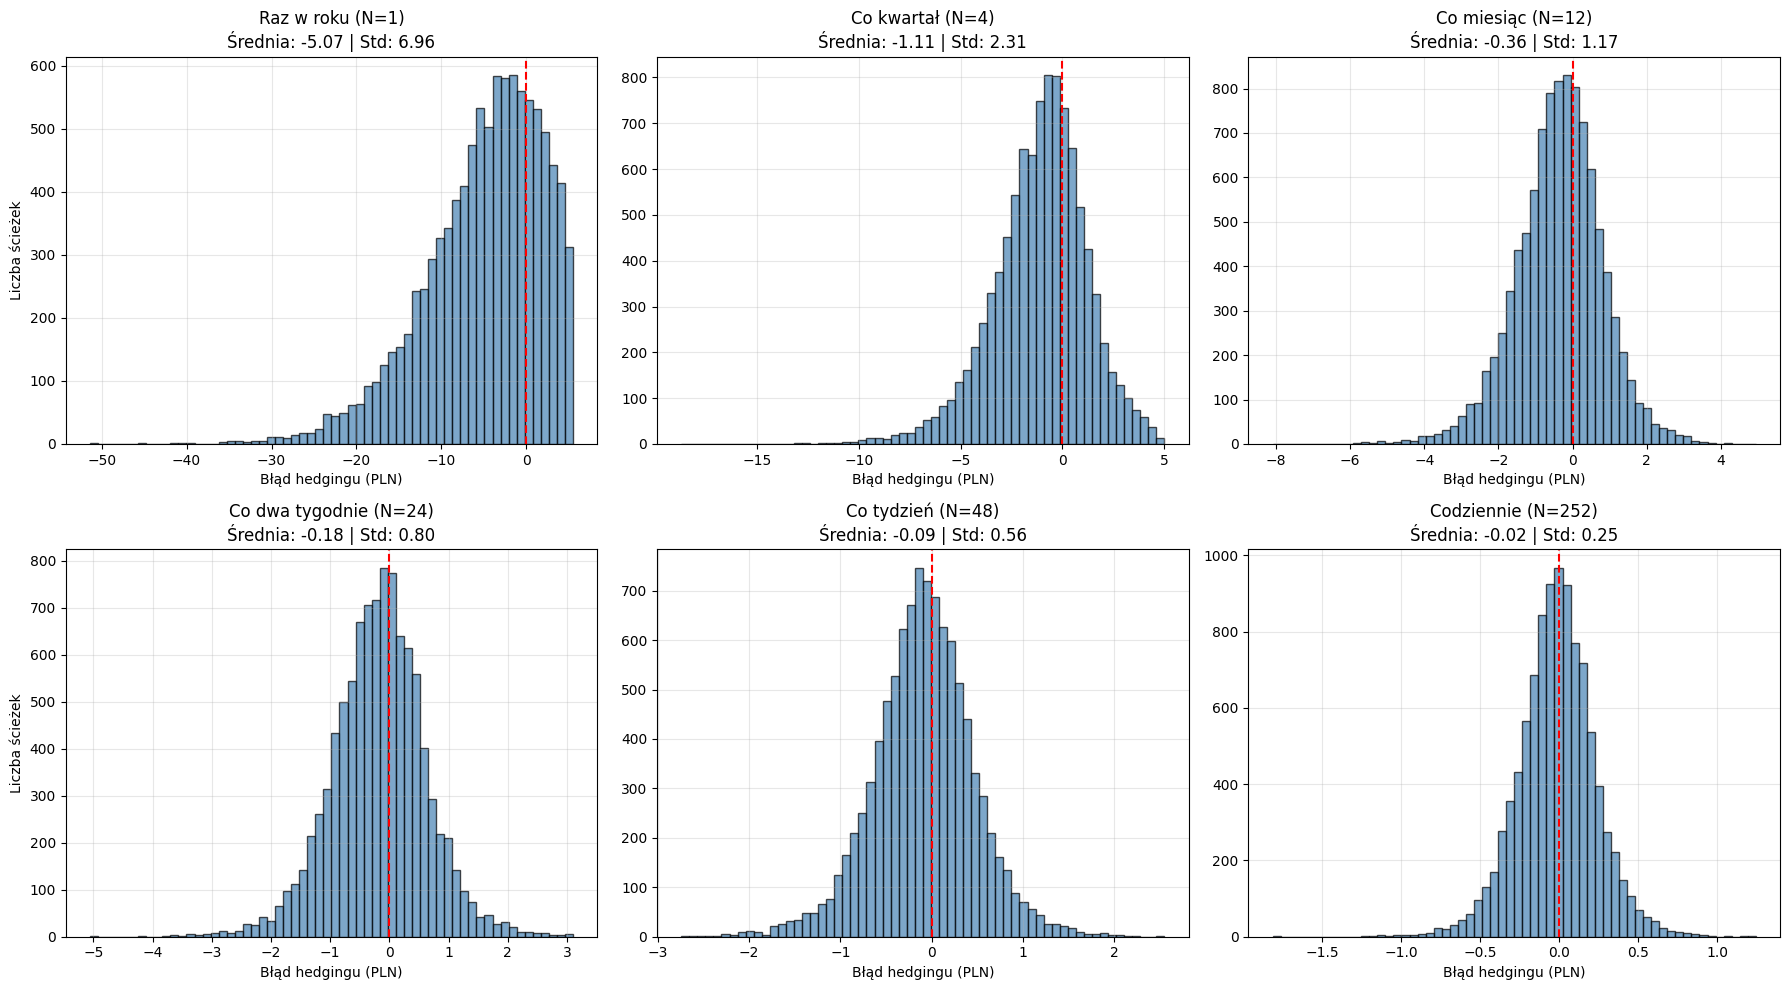

In [132]:
n_paths = 10000

# 6 częstotliwości rehedgingu (liczba kroków w roku)
N_list = [1, 4, 12, 24, 48, 252]
nazwy = ['Raz w roku', 'Co kwartał', 'Co miesiąc', 'Co dwa tygodnie', 'Co tydzień', 'Codziennie']

# Liczymy błędy dla każdej częstotliwości
wszystkie_bledy = []

for N in N_list:
    dt = T / N
    
    time_grid, paths_S, paths_X = simulate_correlated_paths(
        S0_gold, S0_usdpln, mu1, mu2, sigma1, sigma2, rho, dt, T, n_paths
    )
    
    _, _, _, _, _, err = simulate_delta_hedging(
        time_grid, paths_S, paths_X, S0_gold, K, T, r_pln, r_usd, rho, sigma1, sigma2, dt
    )
    
    wszystkie_bledy.append(np.asarray(err).flatten())

# Rysujemy 2 wiersze x 3 kolumny
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i in range(6):
    bledy = wszystkie_bledy[i]
    
    axes[i].hist(bledy, bins=60, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].axvline(0, color='red', linestyle='--', linewidth=1.5)
    
    axes[i].set_title(f'{nazwy[i]} (N={N_list[i]})\nŚrednia: {np.mean(bledy):.2f} | Std: {np.std(bledy):.2f}')
    axes[i].set_xlabel('Błąd hedgingu (PLN)')
    axes[i].grid(True, alpha=0.3)

axes[0].set_ylabel('Liczba ścieżek')
axes[3].set_ylabel('Liczba ścieżek')

plt.tight_layout()
plt.show()


## Wspólne osi

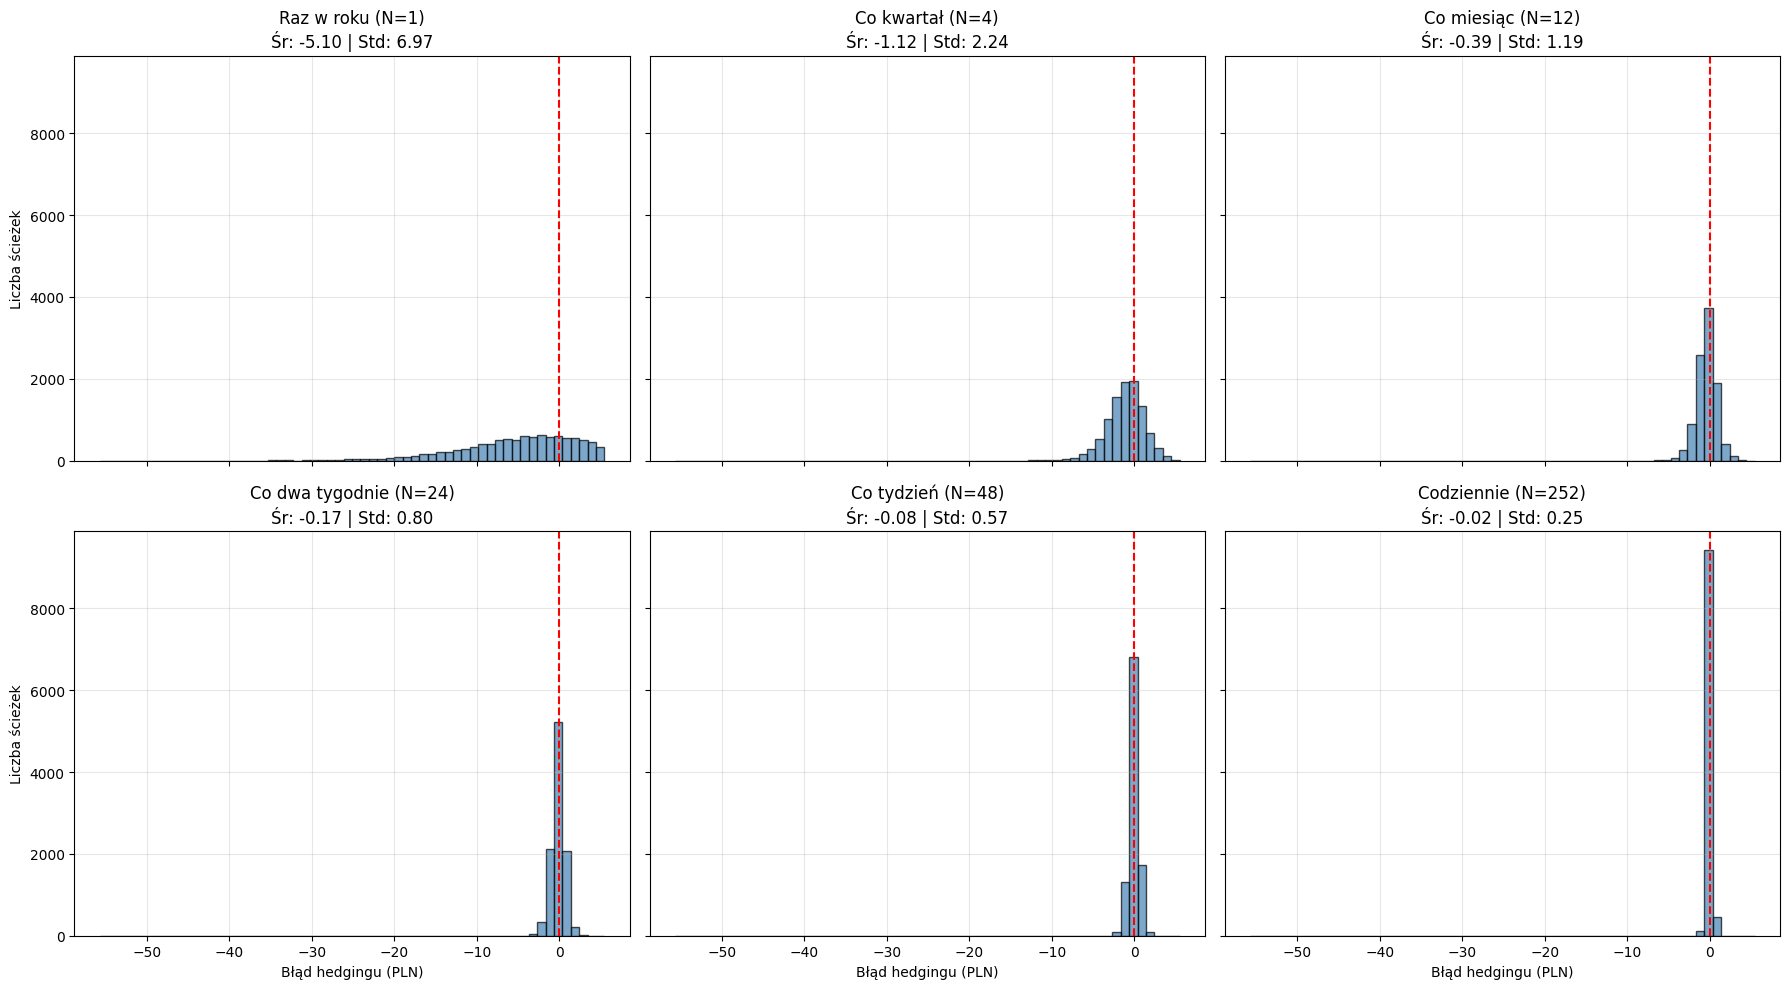

In [133]:
n_paths = 10000

N_list = [1, 4, 12, 24, 48, 252]
nazwy = ['Raz w roku', 'Co kwartał', 'Co miesiąc',
         'Co dwa tygodnie', 'Co tydzień', 'Codziennie']

wszystkie_bledy = []

for N in N_list:
    dt = T / N
    
    time_grid, paths_S, paths_X = simulate_correlated_paths(
        S0_gold, S0_usdpln, mu1, mu2, sigma1, sigma2, rho, dt, T, n_paths
    )
    
    _, _, _, _, _, err = simulate_delta_hedging(
        time_grid, paths_S, paths_X,
        S0_gold, K, T, r_pln, r_usd, rho, sigma1, sigma2, dt
    )
    
    wszystkie_bledy.append(np.asarray(err).flatten())


# === WSPÓLNY ZAKRES OSI X ===
xmin = min(b.min() for b in wszystkie_bledy)
xmax = max(b.max() for b in wszystkie_bledy)

# === RYSOWANIE ZE WSPÓLNYMI OSIAMI ===
fig, axes = plt.subplots(2, 3, figsize=(18, 10),
                         sharex=True, sharey=True)

axes = axes.flatten()

for i in range(6):
    bledy = wszystkie_bledy[i]
    
    axes[i].hist(bledy, bins=60,
                 range=(xmin, xmax),   # wspólny zakres
                 color='steelblue',
                 edgecolor='black',
                 alpha=0.7)
    
    axes[i].axvline(0, color='red', linestyle='--', linewidth=1.5)
    
    axes[i].set_title(
        f'{nazwy[i]} (N={N_list[i]})\n'
        f'Śr: {np.mean(bledy):.2f} | Std: {np.std(bledy):.2f}'
    )
    
    axes[i].grid(True, alpha=0.3)

axes[0].set_ylabel('Liczba ścieżek')
axes[3].set_ylabel('Liczba ścieżek')

for ax in axes[3:]:
    ax.set_xlabel('Błąd hedgingu (PLN)')

plt.tight_layout()
plt.show()

## Centyle 1-99

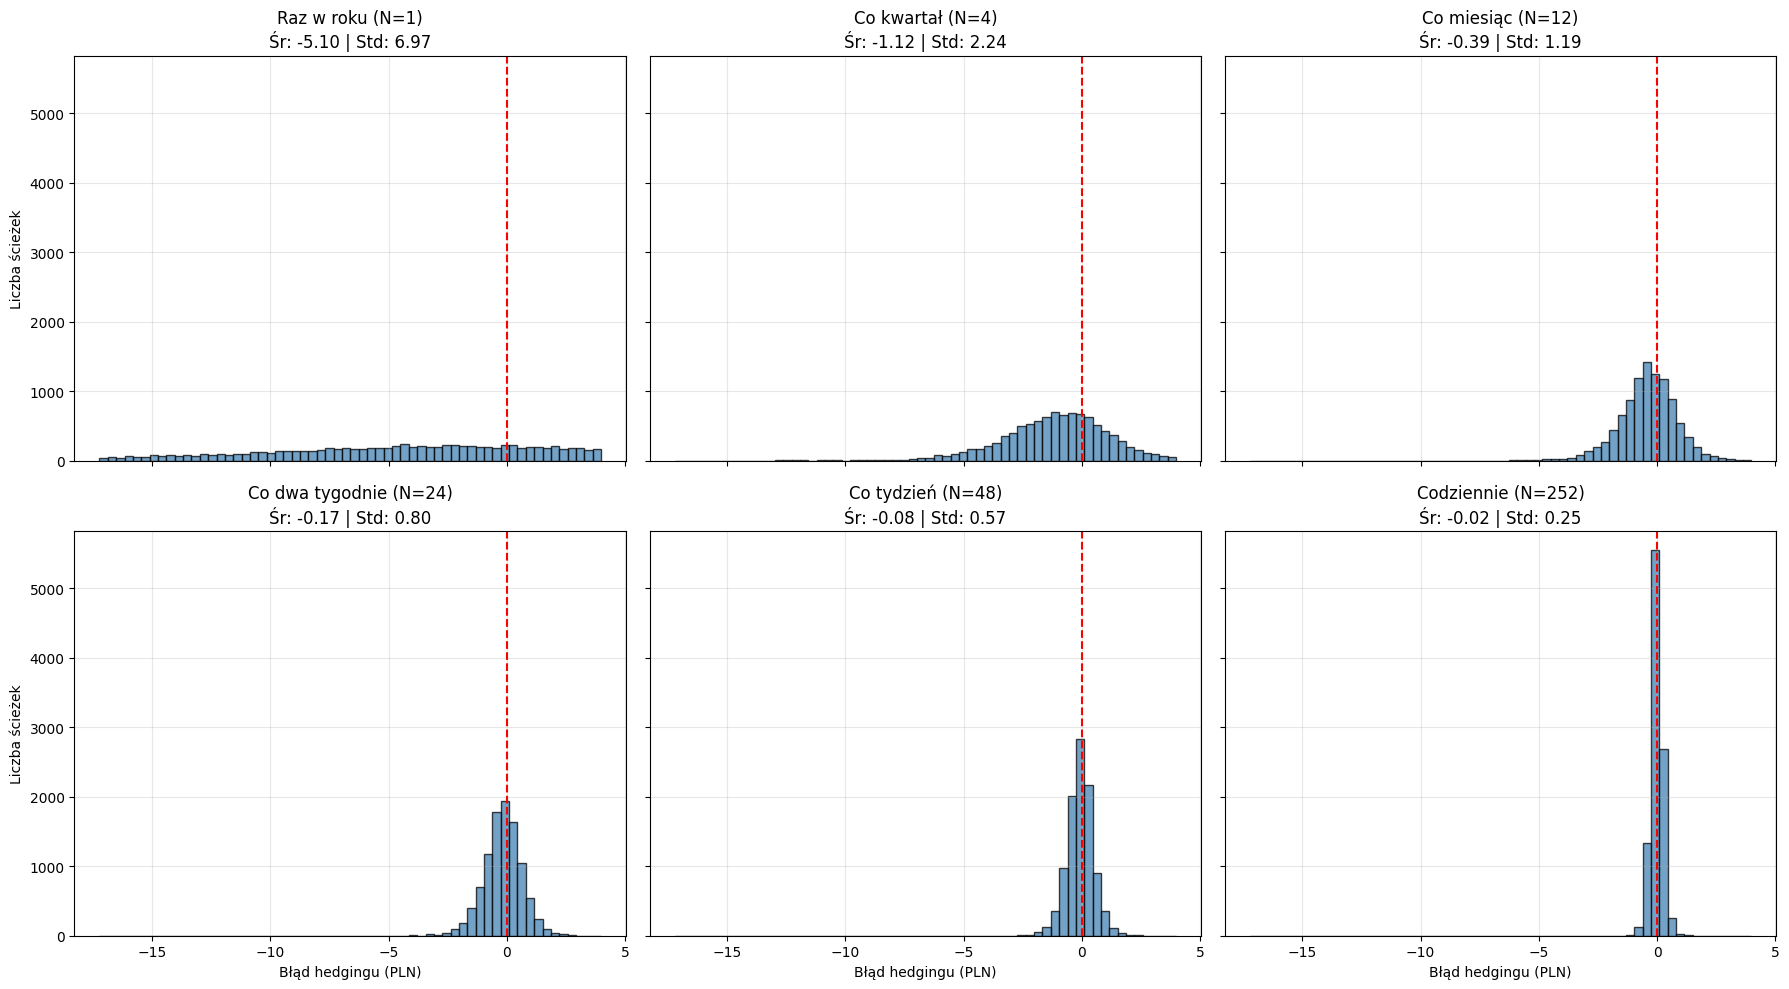

In [134]:
import numpy as np
import matplotlib.pyplot as plt

# ===== WYLICZENIE GLOBALNEGO ZAKRESU 1%-99% =====
all_errors = np.concatenate(wszystkie_bledy)

xmin = np.percentile(all_errors, 1)
xmax = np.percentile(all_errors, 99)

# ===== RYSOWANIE =====
fig, axes = plt.subplots(2, 3, figsize=(18, 10),
                         sharex=True, sharey=True)

axes = axes.flatten()

for i in range(6):
    bledy = wszystkie_bledy[i]
    
    axes[i].hist(
        bledy,
        bins=60,
        range=(xmin, xmax),     # ✅ przycięta oś
        color='steelblue',
        edgecolor='black',
        alpha=0.75
    )
    
    axes[i].axvline(0, color='red', linestyle='--', linewidth=1.5)
    
    axes[i].set_title(
        f'{nazwy[i]} (N={N_list[i]})\n'
        f'Śr: {np.mean(bledy):.2f} | Std: {np.std(bledy):.2f}'
    )
    
    axes[i].grid(True, alpha=0.3)

axes[0].set_ylabel('Liczba ścieżek')
axes[3].set_ylabel('Liczba ścieżek')

for ax in axes[3:]:
    ax.set_xlabel('Błąd hedgingu (PLN)')

plt.tight_layout()
plt.show()